In [2]:
!pip install -q datasets
from datasets import load_dataset
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

tf = transforms.Compose([transforms.CenterCrop(178), transforms.Resize(64),
                         transforms.ToTensor(), transforms.Normalize((.5,)*3, (.5,)*3)])

hf = load_dataset("nielsr/CelebA-faces", split="train[:500]")   # only 500 images

class CelebaSubset(Dataset):
    def __len__(self): return len(hf)
    def __getitem__(self, i):
        return tf(hf[i]["image"].convert("RGB")), 0   # dummy label to match (x, _) loop

data = CelebaSubset()
loader = DataLoader(data, batch_size=128, shuffle=True)

dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  462MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  463MB            

data/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/train-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  463MB            

data/train-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/202599 [00:00<?, ? examples/s]

Epoch 1/5, Loss: 581037139955.2142
Epoch 2/5, Loss: 5111.5144
Epoch 3/5, Loss: 4372.3916
Epoch 4/5, Loss: 3708.3651
Epoch 5/5, Loss: 3226.3158


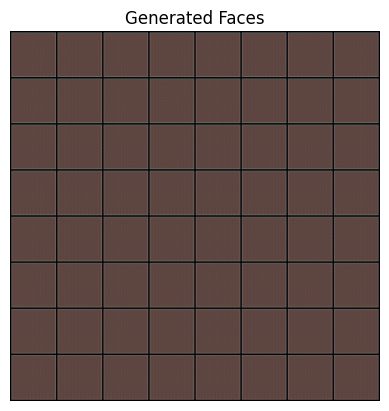

In [3]:
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim, epochs = 100, 5

class VAE(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(), nn.Flatten())
        self.mu = nn.Linear(512*16, d)
        self.logvar = nn.Linear(512*16, d)
        self.fc = nn.Linear(d, 512*16)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh())
    def decode(self, z):
        return self.dec(self.fc(z).view(-1, 512, 4, 4))
    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar

def loss_fn(r, x, mu, logvar):
    return F.mse_loss(r, x, reduction='sum') - 0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())

model = VAE(latent_dim).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for e in range(epochs):
    model.train()
    total = 0
    for x, _ in loader:
        x = x.to(device)
        r, mu, lv = model(x)
        loss = loss_fn(r, x, mu, lv)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"Epoch {e+1}/{epochs}, Loss: {total/len(data):.4f}")

model.eval()
with torch.no_grad():
    imgs = model.decode(torch.randn(64, latent_dim).to(device)).cpu() * 0.5 + 0.5
plt.imshow(torchvision.utils.make_grid(imgs, nrow=8).permute(1, 2, 0))
plt.axis('off'); plt.title("Generated Faces"); plt.show()